# Task 1

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix
import urllib.request

# Download standard hotel bookings dataset
url = "https://raw.githubusercontent.com/swapnilsaurav/Dataset/refs/heads/master/hotel_bookings.csv"
df = pd.read_csv(url)

# Minimal Preprocessing for Baseline
# Drop high-null columns to save time
df_base = df.drop(columns=['company', 'agent', 'reservation_status_date'])
df_base.dropna(inplace=True)

X = df_base.drop('is_canceled', axis=1)
y = df_base['is_canceled']

# Simple Label Encoding for categorical columns
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Baseline Model
baseline_model = LogisticRegression(max_iter=500)
baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("--- Task 1: Baseline Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

--- Task 1: Baseline Results ---
Accuracy: 0.8339
ROC-AUC: 0.8791
F1 Score: 0.7593
Confusion Matrix:
 [[16363  1919]
 [ 2835  7497]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Task 2

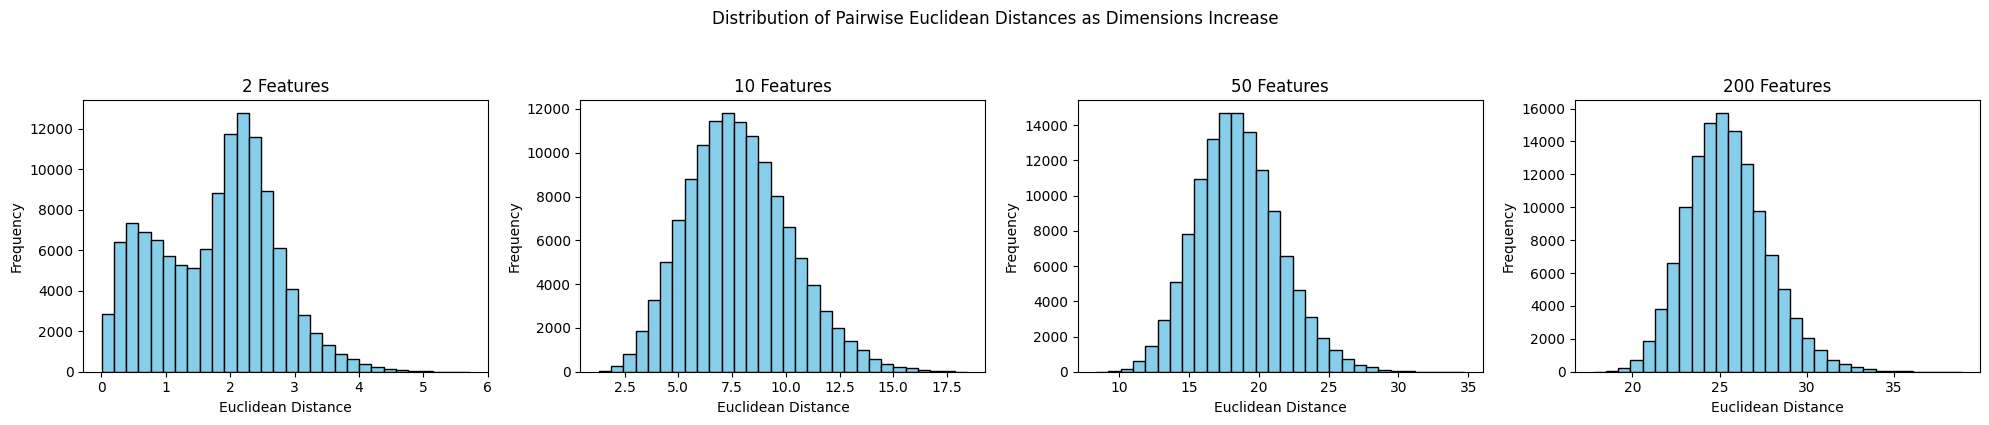

In [8]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics.pairwise import euclidean_distances

dimensions = [2, 10, 50, 200]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for i, dim in enumerate(dimensions):
    # Generate synthetic dataset [cite: 29]
    # Fix: Ensure n_informative is strictly less than n_features and set n_redundant/n_repeated to 0
    n_informative_val = max(1, min(dim - 1, 20)) if dim > 1 else 1
    X_syn, _ = make_classification(n_samples=500, n_features=dim, n_informative=n_informative_val, n_redundant=0, n_repeated=0, n_clusters_per_class=1, random_state=42)

    # Calculate Euclidean distances between random pairs
    dists = euclidean_distances(X_syn)

    # Extract upper triangle (unique pairs)
    unique_dists = dists[np.triu_indices_from(dists, k=1)]

    axes[i].hist(unique_dists, bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f'{dim} Features')
    axes[i].set_xlabel('Euclidean Distance')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Pairwise Euclidean Distances as Dimensions Increase', y=1.05)
plt.tight_layout()
plt.show()

# Task 3

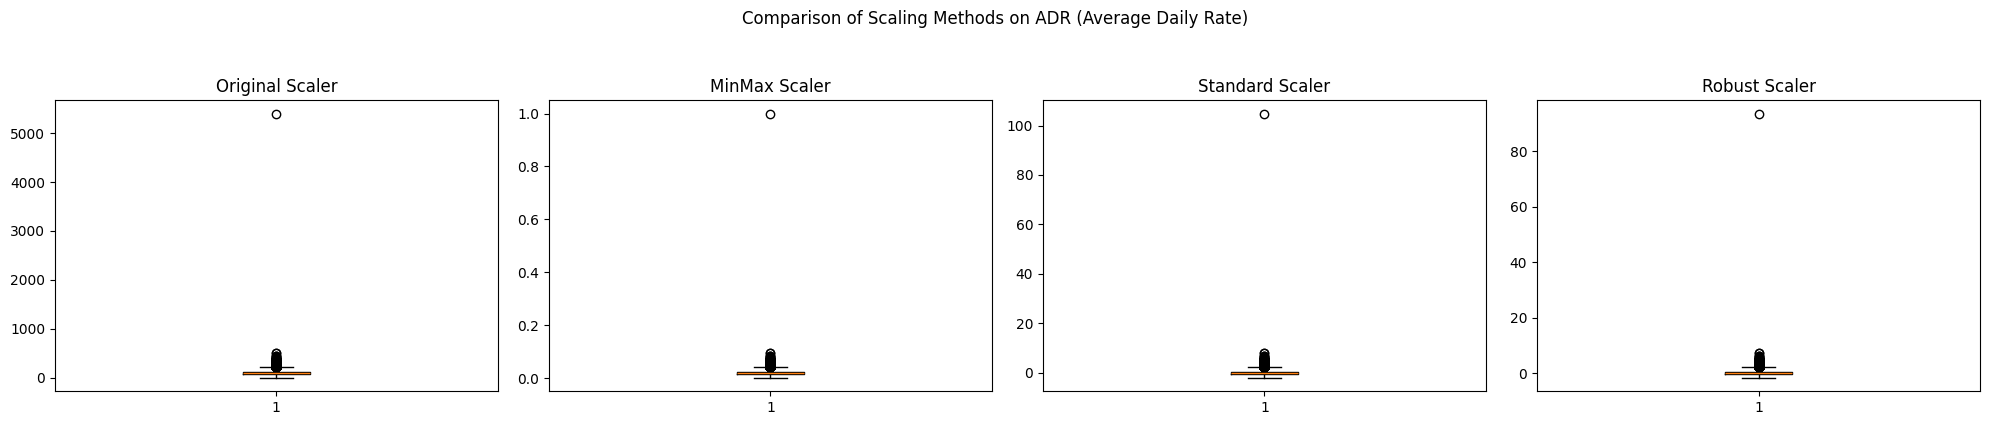

Summary Statistics Change for ADR:
Original: Mean=101.83, Std=50.53, IQR=56.72
MinMax: Mean=0.02, Std=0.01, IQR=0.01
Standard: Mean=-0.00, Std=1.00, IQR=1.12
Robust: Mean=0.13, Std=0.89, IQR=1.00


In [6]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, KBinsDiscretizer

# Select 6 numeric columns [cite: 41]
num_cols = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'previous_cancellations', 'adr']
df_num = df[num_cols].copy().dropna()

# 1. Binning (Quantile bins for lead_time and equal width for stays_in_week_nights) [cite: 43, 44]
kbd_quantile = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
df_num['lead_time_binned'] = kbd_quantile.fit_transform(df_num[['lead_time']])

kbd_uniform = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='uniform')
df_num['stays_week_binned'] = kbd_uniform.fit_transform(df_num[['stays_in_week_nights']])

# 2. Binarization (high_value_customer = 1 if adr > 100) [cite: 45, 46]
df_num['high_value_customer'] = (df_num['adr'] > 100).astype(int)

# 3. Compare Scalers on 'adr' [cite: 47]
scalers = {
    'Original': None,
    'MinMax': MinMaxScaler(), # [cite: 48]
    'Standard': StandardScaler(), # [cite: 50]
    'Robust': RobustScaler() # [cite: 52]
}

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
adr_data = df_num[['adr']]

for i, (name, scaler) in enumerate(scalers.items()):
    if scaler:
        scaled_adr = scaler.fit_transform(adr_data)
    else:
        scaled_adr = adr_data.values

    axes[i].boxplot(scaled_adr)
    axes[i].set_title(f'{name} Scaler')

plt.suptitle('Comparison of Scaling Methods on ADR (Average Daily Rate)', y=1.05)
plt.tight_layout()
plt.show()

# Summary Stats
print("Summary Statistics Change for ADR:")
for name, scaler in scalers.items():
    data = scaler.fit_transform(adr_data).flatten() if scaler else adr_data.values.flatten()
    print(f"{name}: Mean={np.mean(data):.2f}, Std={np.std(data):.2f}, IQR={np.percentile(data, 75) - np.percentile(data, 25):.2f}")

# Task 4

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Sub-sample for KNN speed
df_knn = df_num.sample(2000, random_state=42)
X_k = df_knn.drop('high_value_customer', axis=1) # Using a dummy target for this demo
y_k = df_knn['high_value_customer']
X_tr, X_te, y_tr, y_te = train_test_split(X_k, y_k, test_size=0.3, random_state=42)

# 1. Without Scaling
knn_unscaled = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_unscaled.fit(X_tr, y_tr)
print(f"Unscaled KNN Accuracy: {accuracy_score(y_te, knn_unscaled.predict(X_te)):.4f}")

# 2. StandardScaler
scaler_s = StandardScaler()
X_tr_s = scaler_s.fit_transform(X_tr)
X_te_s = scaler_s.transform(X_te)
knn_s = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_s.fit(X_tr_s, y_tr)
print(f"StandardScaler KNN Accuracy: {accuracy_score(y_te, knn_s.predict(X_te_s)):.4f}")

# 3. RobustScaler + Manhattan Metric
scaler_r = RobustScaler()
X_tr_r = scaler_r.fit_transform(X_tr)
X_te_r = scaler_r.transform(X_te)
knn_r = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_r.fit(X_tr_r, y_tr)
print(f"RobustScaler + Manhattan KNN Accuracy: {accuracy_score(y_te, knn_r.predict(X_te_r)):.4f}")

Unscaled KNN Accuracy: 0.9817
StandardScaler KNN Accuracy: 0.9317
RobustScaler + Manhattan KNN Accuracy: 0.9483


# Task 5

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, OneHotEncoder
from sklearn.model_selection import cross_val_score

# Define columns
numeric_features = ['lead_time', 'adr', 'stays_in_week_nights']
categorical_features = ['hotel', 'market_segment']

# Clean subset for pipeline
df_pipe = df[numeric_features + categorical_features + ['is_canceled']].dropna()
X_p = df_pipe.drop('is_canceled', axis=1)
y_p = df_pipe['is_canceled']

# Create Transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('power_transform', PowerTransformer(method='yeo-johnson'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Final Pipeline
clf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', LogisticRegression(max_iter=1000))])

# Cross Validation
scores = cross_val_score(clf_pipeline, X_p, y_p, cv=5, scoring='roc_auc')
print(f"Pipeline 5-Fold ROC-AUC: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

Pipeline 5-Fold ROC-AUC: 0.6881 (+/- 0.1149)


#  Task 6 & 7


In [13]:
# Create a fresh copy for feature engineering
df_fe = df.copy()

# TASK 6: EXTRACTION
# A) Date Features (Pseudo dates from columns)
month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
             'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
df_fe['arrival_month_num'] = df_fe['arrival_date_month'].map(month_map)
df_fe['is_weekend_arrival'] = df_fe['stays_in_weekend_nights'].apply(lambda x: 1 if x > 0 else 0)

# TASK 7: CONSTRUCTION
# 1. Ratios
df_fe['price_per_person'] = df_fe['adr'] / (df_fe['adults'] + df_fe['children'] + 1) # +1 avoids div by zero
df_fe['special_requests_rate'] = df_fe['total_of_special_requests'] / (df_fe['stays_in_weekend_nights'] + df_fe['stays_in_week_nights'] + 1)

# 2. Interactions
df_fe['adr_lead_time_interaction'] = df_fe['adr'] * df_fe['lead_time']
df_fe['total_guests'] = df_fe['adults'] + df_fe['children'] + df_fe['babies']

# 3. Polynomial (Manual implementation for clarity)
df_fe['lead_time_squared'] = df_fe['lead_time'] ** 2

# 4. Aggregated / Group Feature (Leakage prevention implemented by using transform)
# Calculate mean ADR by hotel type
hotel_adr_mean = df_fe.groupby('hotel')['adr'].transform('mean')
df_fe['hotel_avg_adr_diff'] = df_fe['adr'] - hotel_adr_mean

print("Constructed Features Head:\n", df_fe[['price_per_person', 'special_requests_rate', 'adr_lead_time_interaction', 'total_guests', 'hotel_avg_adr_diff']].head())

Constructed Features Head:
    price_per_person  special_requests_rate  adr_lead_time_interaction  \
0          0.000000               0.000000                        0.0   
1          0.000000              10.000000                        0.0   
2         37.500000               0.000000                      525.0   
3         37.500000               0.000000                      975.0   
4         32.666667               0.333333                     1372.0   

   total_guests  hotel_avg_adr_diff  
0           2.0          -94.946564  
1           2.0          -94.946564  
2           1.0          -19.946564  
3           1.0          -19.946564  
4           2.0            3.053436  


# Task 8

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Clean data for Random Forest
df_rf = df_fe.select_dtypes(include=[np.number]).dropna()
X_rf = df_rf.drop(['is_canceled', 'arrival_date_year'], axis=1) # Drop target and non-predictive year
y_rf = df_rf['is_canceled']

# Correlation Filtering (Remove > 0.85)
corr_matrix = X_rf.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
X_rf_filtered = X_rf.drop(columns=to_drop)

# Random Forest Importance
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_rf_filtered, y_rf)

importances = pd.Series(rf.feature_importances_, index=X_rf_filtered.columns).sort_values(ascending=False)
print("Top 15 Features (Random Forest):\n", importances.head(15))

Top 15 Features (Random Forest):
 id                                0.146350
adr                               0.132561
lead_time                         0.121827
adults                            0.111859
arrival_date_day_of_month         0.102613
arrival_date_week_number          0.082564
company                           0.076970
agent                             0.048149
previous_bookings_not_canceled    0.034273
booking_changes                   0.030441
is_repeated_guest                 0.029302
is_weekend_arrival                0.019830
total_of_special_requests         0.018489
special_requests_rate             0.017944
stays_in_weekend_nights           0.016270
dtype: float64
